In [1]:
# Repo-root bootstrap: find the directory containing the `llm_perf` package
# (walking up from CWD) and chdir there so paths like "llm_perf/database/..."
# and "assets/..." resolve regardless of where the notebook lives on disk.
import os
from pathlib import Path
_p = Path.cwd()
while not (_p / "llm_perf" / "__init__.py").exists():
    if _p == _p.parent:
        raise RuntimeError("Could not find llm_perf repo root from " + str(Path.cwd()))
    _p = _p.parent
os.chdir(_p)
print("cwd:", Path.cwd())

cwd: /Users/jasonlu/Projects/ai.cluster/llm_perf


# Partition-Optimal Pareto Frontiers vs. Kernel-Launch Latency

**Question:** how does per-kernel CPU dispatch latency `τ_launch` shift the (throughput/GPU, interactivity) Pareto frontier on GB200 NVL72 with NVLS / SHARP in-network collectives **on**, and does it change which (PP, TP, EP, SP) partition wins?

**Why τ_launch (not a constant `t_oh`):** unlike a fixed framework overhead added post-hoc, kernel-launch latency multiplies a partition-dependent kernel count:

$$t_{SW} \;=\; \tau_{launch} \cdot \bigg[\tfrac{L}{PP}\big(k_c + k_{coll}(n_{TP}+n_{SP})\big) + \tfrac{L_{moe}}{PP}\, k_{coll}\, n_{EP} + k_{pp\_hop}\bigg]$$

Wider TP / EP shapes fire more collective launches per layer, so they take a bigger hit per `τ_launch` increment than narrower shapes. Deeper PP shrinks `L/PP` and lowers the launch count per stage. So the SW dispatch tax is **not uniform across partitions** — each anchor needs a fresh sweep, not a post-hoc shift.

$$t_{stage} \;=\; t_{stage,hw} + \max\!\big(0,\; t_{SW} - \rho_{SW}\cdot t_{stage,hw}\big)$$

When `t_SW ≫ t_stage,hw` (low B, deep TP, eager mode) the dispatch becomes the binding floor and the GPU goes idle waiting for the next launch.

**INC on:** the system loads `gb200.nvl72.nvls.json` with NVLink SHARP enabled (`inc_enabled=True`, the tuner default). NVLS collapses AR/AG `n_α` to 2 and doubles BW_eff for AR — so the comm term is already at its hardware floor and any remaining sensitivity comes from `t_SW` rather than `t_comm`.

Model, system, and tuner are configured in Section 1 — swap the database paths there to study a different setup.

## 1. Imports and spec loading

In [2]:
from __future__ import annotations

import math
from copy import deepcopy
from dataclasses import dataclass

import matplotlib.pyplot as plt

from llm_perf import InferenceCalculator
from llm_perf.core.collective_algo_opt import optimize_collective_algorithms
from llm_perf.core.kv_paging_model import KVPagingConfig, compute_kv_paging
from llm_perf.core.memory_model import compute_memory
from llm_perf.io import load_model_spec, load_system_spec, load_tuning_spec
from llm_perf.specs.partition_spec import PartitionSpec
from llm_perf.specs.system_spec import span_tiers

# Configuration — GPT-1.8T MoE @ FP4 on GB200 NVL72 with NVLS / SHARP
# in-network collectives ENABLED (tuner default `inc_enabled=True`).
MODEL = "llm_perf/database/model/gpt_1_8t_moe.json"
SYSTEM = "llm_perf/database/system/gb200.nvl72.nvls.json"
TUNER = "llm_perf/database/tuner/gpt_1_8t_moe.tuner.json"

S_DECODE = 8192
BPP_FP4 = 0.5

model = load_model_spec(MODEL)
model.bytes_per_param = BPP_FP4
system = load_system_spec(SYSTEM)
tuner_base = load_tuning_spec(TUNER)
tuner_base.S_decode = S_DECODE
tuner_base.B_decode = 1
# Resolve `auto` algorithms each (partition, B) below; INC stays on.
tuner_base.tp_algorithm_decode = tuner_base.tp_algorithm_prefill = "auto"
tuner_base.ep_algorithm_decode = tuner_base.ep_algorithm_prefill = "auto"
assert tuner_base.inc_enabled, "INC must stay enabled for this notebook"

hbm_bw = system.device.hbm_bandwidth_GBps
base_alpha, base_bw, _ = span_tiers(system.get_tier_chain('TP'), 2)
peak_tf = system.device.peak_flops_TF
tier0 = system.fabrics['nvlink5'].tiers[0]
print(f"Model:  {model.name}  L={model.L}  H={model.H}  n_kv={model.n_kv}  experts={model.moe.n_experts}  k_active={model.moe.k_active}  bytes/param={model.bytes_per_param}")
print(f"System: {system.num_devices} GPUs  HBM={hbm_bw:.0f} GB/s  peak={peak_tf:.0f} TF (FP16, scales linearly with bytes/param)")
print(f"        scale-up: {base_bw:.0f} GB/s · {base_alpha:.2f} μs sw α  |  INC: {tier0.inc!r} @ {tier0.inc_alpha_us:.2f} μs hw α")
print(f"        kernels: k_compute={tuner_base.kernels_per_layer_compute}, k_collective={tuner_base.kernels_per_collective_call}, k_pp_hop={tuner_base.kernels_per_pp_hop}, ρ_SW={tuner_base.sw_overlap_factor}")

Model:  GPT-1.8T-MoE  L=120  H=20480  n_kv=16  experts=16  k_active=2  bytes/param=0.5
System: 72 GPUs  HBM=8000 GB/s  peak=2250 TF (FP16, scales linearly with bytes/param)
        scale-up: 900 GB/s · 0.50 μs sw α  |  INC: 'sharp_class' @ 0.20 μs hw α
        kernels: k_compute=10, k_collective=2, k_pp_hop=2, ρ_SW=1.0


## 2. Partition enumeration

Same constraints as `pareto_basic` / `pareto_vs_overhead`:

- **`PP ≤ 8`** — operational cap. Library default is 32; pinned to 8 here.
- `TP ≤ min(n_kv, n_experts) = 16`.
- `EP ≤ n_experts = 16`.
- `TP · EP ≤ scale_up_domain` (NVL72 → 72 ranks, single tier).
- `SP ∈ [1, 2, 4, 8, 16, 32, 64]`.
- `PP · TP · EP · SP ≤ num_devices = 72`.

In [3]:
PP_MAX = 8   # Operational cap; raise to 32 for unbounded-PP analysis.

from llm_perf.utils import (
    enumerate_partitions as _enumerate_partitions,
    describe_constraints,
)


def enumerate_partitions(num_devices: int) -> list[PartitionSpec]:
    """Local shim around llm_perf.utils.enumerate_partitions; pins (model, system, pp_max)."""
    return _enumerate_partitions(model, system, num_devices=num_devices, pp_max=PP_MAX)


print(describe_constraints(model, system, pp_max=PP_MAX))

partitions = enumerate_partitions(system.num_devices)
print(f"Valid partitions: {len(partitions)}")

PP ≤ 8; TP ≤ min(n_kv=16, n_experts=16) = 16; EP ≤ n_experts=16; TP·EP ≤ scale_up=72 (tier_idx=0)
Valid partitions: 260


## 3. Partition sweep — one full sweep per `τ_launch` anchor

Each `τ_launch` anchor maps onto a serving-stack regime. Order-of-magnitude estimates — actual values vary with framework version, kernel-fusion aggressiveness, and CUDA Graph hit rate.

| `τ_launch` | Stack regime |
|---|---|
| **0 μs**  | SW dispatch disabled — pure-roofline baseline (theoretical floor). |
| **1.5 μs** | CUDA Graphs replay, steady state (TensorRT-LLM, vLLM v1, SGLang). Production default in `tuner_spec.py`. |
| **3 μs**  | CUDA Graphs with light Python in the hot path (vLLM v0.x, well-tuned TGI). |
| **7 μs**  | Eager-mode PyTorch, no graph capture. Per-kernel `cudaLaunchKernel` from Python. |
| **15 μs** | Heavy custom Python scheduler / extra host-side bookkeeping per launch. |
| **30 μs** | Per-kernel host–device sync (debug / profiling builds, very unoptimized stack). |

Because `t_SW` depends on the partition (kernel count = `(L/PP) · (k_c + k_coll · (n_TP+n_SP)) + (L_moe/PP) · k_coll · n_EP + k_pp_hop`), each anchor requires its own sweep — we cannot just shift a cached `t_step` post-hoc.

In [4]:
@dataclass
class Point:
    partition: PartitionSpec
    B: int
    tput_per_gpu: float
    interactivity: float
    TPOT_ms: float
    t_SW_ms: float
    sw_bound: bool       # True when t_SW > t_stage,hw (dispatch is the binding floor)

    @property
    def part_label(self) -> str:
        p = self.partition
        return f"PP={p.PP} TP={p.TP} EP={p.EP} SP={p.SP}"


def log_spaced_batch_sizes(b_max: int) -> list[int]:
    if b_max <= 1:
        return [1]
    n = max(int(math.log10(b_max) * 10), 16)
    raw = {1, b_max}
    for i in range(n + 1):
        raw.add(max(1, int(round(10 ** (i * math.log10(b_max) / n)))))
    p = 1
    while p <= b_max:
        raw.add(p)
        p *= 2
    return sorted(raw)


def sweep_partition(model, system, partition, tuner_template) -> list[Point]:
    """Run the calculator at every B for one partition, given a tuner with `τ_launch` already set."""
    try:
        mem = compute_memory(model, system, partition, tuner_template)
    except Exception:
        return []
    paging = KVPagingConfig(block_size=16, beam_width=1, system_overhead_GB=1.5)
    kv = compute_kv_paging(model, system, partition, tuner_template, mem, paging)
    b_max = int(kv.max_sequences)
    if b_max < 1:
        return []
    replica = partition.PP * partition.TP * partition.EP * partition.SP
    DP = max(1, system.num_devices // replica)
    pts: list[Point] = []
    for B in log_spaced_batch_sizes(b_max):
        tuner = deepcopy(tuner_template)
        tuner.B_decode = B
        tuner = optimize_collective_algorithms(model, partition, system, tuner)
        try:
            r = InferenceCalculator(model, system, partition, tuner).run()
        except Exception:
            continue
        if r.latency.TPOT <= 0:
            continue
        # SW-bound flag: dispatch budget exceeds GPU step time before overlap.
        sw_bound = bool(r.latency.t_SW > r.latency.t_stage)
        pts.append(Point(
            partition=partition, B=B,
            tput_per_gpu=(B * DP) / (r.latency.TPOT * system.num_devices),
            interactivity=1.0 / r.latency.TPOT,
            TPOT_ms=r.latency.TPOT * 1e3,
            t_SW_ms=r.latency.t_SW * 1e3,
            sw_bound=sw_bound,
        ))
    return pts


def pareto_frontier(points: list[Point]) -> list[Point]:
    sorted_pts = sorted(points, key=lambda p: (-p.tput_per_gpu, -p.interactivity))
    frontier: list[Point] = []
    best_interact = -math.inf
    for p in sorted_pts:
        if p.interactivity > best_interact + 1e-9:
            frontier.append(p)
            best_interact = p.interactivity
    frontier.sort(key=lambda p: p.tput_per_gpu)
    return frontier

In [5]:
# τ_launch anchors (μs/kernel) → approximate stack regime.
TAU_LAUNCH_US = [0.0, 1.5, 3.0, 7.0, 15.0, 30.0]

kl_frontiers: dict[float, list[Point]] = {}
kl_clouds:    dict[float, list[Point]] = {}
for tau_us in TAU_LAUNCH_US:
    tuner_anchor = deepcopy(tuner_base)
    tuner_anchor.kernel_launch_us = tau_us
    cloud: list[Point] = []
    for part in partitions:
        cloud.extend(sweep_partition(model, system, part, tuner_anchor))
    fr = pareto_frontier(cloud)
    n_sw_bound = sum(1 for p in fr if p.sw_bound)
    kl_clouds[tau_us]    = cloud
    kl_frontiers[tau_us] = fr
    print(f"τ_launch = {tau_us:>5.1f} μs  |  cloud={len(cloud):>5d}  frontier={len(fr):>3d}  sw-bound on frontier={n_sw_bound}/{len(fr)}")

τ_launch =   0.0 μs  |  cloud= 5895  frontier= 40  sw-bound on frontier=0/40


τ_launch =   1.5 μs  |  cloud= 5895  frontier= 40  sw-bound on frontier=0/40


τ_launch =   3.0 μs  |  cloud= 5895  frontier= 40  sw-bound on frontier=0/40
τ_launch =   7.0 μs  |  cloud= 5895  frontier= 37  sw-bound on frontier=0/37


τ_launch =  15.0 μs  |  cloud= 5895  frontier= 37  sw-bound on frontier=19/37
τ_launch =  30.0 μs  |  cloud= 5895  frontier= 37  sw-bound on frontier=25/37


## 4. Winners summary

Does the per-corner winner change with `τ_launch`? With INC on, the comm term is already at its hardware floor, so any partition reshuffle here is driven purely by the SW dispatch tax.

Wider TP / more layers per stage → more launches per microbatch → worse under high `τ_launch`. So we expect deeper PP (smaller `L/PP`) and narrower TP / EP to gain ground as `τ_launch` grows.

In [6]:
def winners(frontier: list[Point]) -> list[tuple[str, int]]:
    counts: dict[str, int] = {}
    for p in frontier:
        counts[p.part_label] = counts.get(p.part_label, 0) + 1
    return sorted(counts.items(), key=lambda kv: -kv[1])


for tau_us, fr in kl_frontiers.items():
    w = winners(fr)
    top = ", ".join(f"{k} ({v})" for k, v in w)
    head = "τ_launch =  0 μs (SW off)" if tau_us == 0 else f"τ_launch = {tau_us:>4.1f} μs"
    print(f"  {head}")
    print(f"    winners: {top}")

  τ_launch =  0 μs (SW off)
    winners: PP=8 TP=8 EP=1 SP=1 (35), PP=4 TP=16 EP=1 SP=1 (3), PP=6 TP=4 EP=1 SP=1 (2)
  τ_launch =  1.5 μs
    winners: PP=8 TP=8 EP=1 SP=1 (35), PP=4 TP=16 EP=1 SP=1 (3), PP=6 TP=4 EP=1 SP=1 (2)
  τ_launch =  3.0 μs
    winners: PP=8 TP=8 EP=1 SP=1 (35), PP=4 TP=16 EP=1 SP=1 (3), PP=6 TP=4 EP=1 SP=1 (2)
  τ_launch =  7.0 μs
    winners: PP=8 TP=8 EP=1 SP=1 (35), PP=6 TP=4 EP=1 SP=1 (2)
  τ_launch = 15.0 μs
    winners: PP=8 TP=8 EP=1 SP=1 (35), PP=6 TP=4 EP=1 SP=1 (2)
  τ_launch = 30.0 μs
    winners: PP=8 TP=8 EP=1 SP=1 (35), PP=6 TP=4 EP=1 SP=1 (2)


## 5. Pareto plot

X = interactivity (1/TPOT), Y = throughput/GPU. SW-bound frontier points (where `t_SW > t_stage,hw`, the dispatch is binding) are marked with hollow squares; HW-bound points are filled circles.

Saved -> assets/pareto_vs_kernel_launch.png


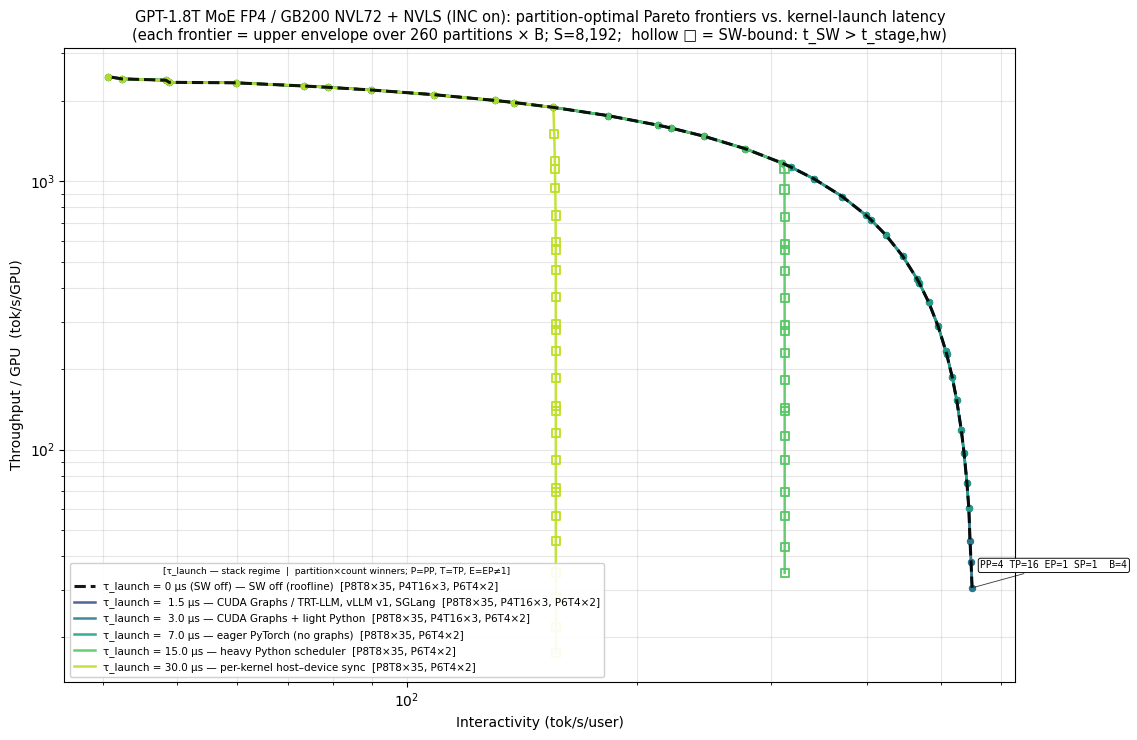

In [7]:
def winners_tag(frontier: list[Point]) -> str:
    """Compact label for legend: P=PP T=TP E=EP (drops EP=1 SP=1)."""
    counts: dict[str, int] = {}
    for p in frontier:
        counts[p.part_label] = counts.get(p.part_label, 0) + 1
    def short(name: str) -> str:
        return (name.replace(" EP=1", "").replace(" SP=1", "")
                    .replace("PP=", "P").replace("TP=", "T")
                    .replace("EP=", "E").replace(" ", ""))
    items = sorted(counts.items(), key=lambda kv: -kv[1])
    return ", ".join(f"{short(k)}×{v}" for k, v in items)


STACK_TAG: dict[float, str] = {
    0.0:  "SW off (roofline)",
    1.5:  "CUDA Graphs / TRT-LLM, vLLM v1, SGLang",
    3.0:  "CUDA Graphs + light Python",
    7.0:  "eager PyTorch (no graphs)",
    15.0: "heavy Python scheduler",
    30.0: "per-kernel host–device sync",
}


def annotate_baseline(ax, frontier, color="black"):
    if not frontier:
        return
    seen: set[str] = set()
    picks: list[int] = []
    for i, p in enumerate(frontier):
        if p.part_label not in seen:
            seen.add(p.part_label); picks.append(i)
    min_dx = 0.05 * max((p.interactivity for p in frontier), default=1.0)
    last_x = -math.inf
    kept: list[int] = []
    for idx in picks:
        x = frontier[idx].interactivity
        if x - last_x >= min_dx:
            kept.append(idx); last_x = x
    offsets = [(6, 14), (6, -20), (6, 32), (6, -38)]
    for j, idx in enumerate(kept):
        p = frontier[idx]
        dx, dy = offsets[j % len(offsets)]
        ax.annotate(
            f"{p.part_label}  B={p.B}",
            xy=(p.interactivity, p.tput_per_gpu),
            xytext=(dx, dy), textcoords="offset points",
            fontsize=7, family="monospace", color="black", ha="left",
            bbox=dict(boxstyle="round,pad=0.22", fc="white",
                      ec=color, alpha=0.95, lw=0.7),
            arrowprops=dict(arrowstyle="-", color=color, lw=0.6, alpha=0.8),
        )


fig, ax = plt.subplots(figsize=(11.5, 7.5))
cmap = plt.get_cmap("viridis")
anchors = list(kl_frontiers.keys())
colors = [cmap(0.10 + 0.80 * i / max(1, len(anchors) - 1)) for i in range(len(anchors))]


def legend_label(tau_us: float, fr: list[Point]) -> str:
    tag = STACK_TAG.get(tau_us, "")
    head = "τ_launch = 0 μs (SW off)" if tau_us == 0 else f"τ_launch = {tau_us:>4.1f} μs"
    return f"{head} — {tag}  [{winners_tag(fr)}]"


# Baseline (τ_launch = 0, SW disabled) drawn as dashed black reference.
zero_fr = kl_frontiers.get(0.0, [])
if zero_fr:
    ax.plot([p.interactivity for p in zero_fr],
            [p.tput_per_gpu for p in zero_fr],
            "--", lw=2.2, color="black", alpha=0.9,
            label=legend_label(0.0, zero_fr), zorder=6)

for (tau_us, fr), color in zip(kl_frontiers.items(), colors):
    if not fr or tau_us == 0.0:
        continue
    xs = [p.interactivity for p in fr]
    ys = [p.tput_per_gpu for p in fr]
    ax.plot(xs, ys, "-", lw=1.8, color=color, alpha=0.9,
            label=legend_label(tau_us, fr))
    # Split markers: filled circle = HW-bound, hollow square = SW-bound.
    hw_x = [p.interactivity for p in fr if not p.sw_bound]
    hw_y = [p.tput_per_gpu  for p in fr if not p.sw_bound]
    sw_x = [p.interactivity for p in fr if p.sw_bound]
    sw_y = [p.tput_per_gpu  for p in fr if p.sw_bound]
    ax.scatter(hw_x, hw_y, s=18, color=color, alpha=0.85, zorder=3, marker="o")
    ax.scatter(sw_x, sw_y, s=34, facecolors="none", edgecolors=color,
               linewidths=1.4, alpha=0.95, zorder=4, marker="s")

if zero_fr:
    annotate_baseline(ax, zero_fr, "black")

ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("Interactivity (tok/s/user)")
ax.set_ylabel("Throughput / GPU  (tok/s/GPU)")
ax.set_title(
    f"GPT-1.8T MoE FP4 / GB200 NVL72 + NVLS (INC on): partition-optimal Pareto frontiers vs. kernel-launch latency\n"
    f"(each frontier = upper envelope over {len(partitions)} partitions × B; "
    f"S={S_DECODE:,};  hollow □ = SW-bound: t_SW > t_stage,hw)",
    fontsize=10.5,
)
ax.grid(True, which="both", alpha=0.3)
ax.legend(
    loc="lower left", fontsize=7.5, framealpha=0.92,
    title="[τ_launch — stack regime  |  partition×count winners; P=PP, T=TP, E=EP≠1]",
    title_fontsize=6.5,
)
fig.tight_layout()
fig.savefig("assets/pareto_vs_kernel_launch.png", dpi=130, bbox_inches="tight")
print("Saved -> assets/pareto_vs_kernel_launch.png")
plt.show()

### Why the cliffs?  (ρ_SW = 1.0 here — full SW/HW overlap)

Once `t_SW > t_stage,hw`, the dispatch overlap term in the step-time formula

$$t_{step} \;=\; t_{stage,hw} + \max\!\big(0,\; t_{SW} - \rho_{SW}\cdot t_{stage,hw}\big)$$

clamps the step time to **`t_step ≈ t_SW`**, since the GPU has finished the work and is now waiting on the next launch. And

$$t_{SW} \;=\; \tau_{launch} \cdot \bigg[\tfrac{L}{PP}\big(k_c + k_{coll}(n_{TP}+n_{SP})\big) + \tfrac{L_{moe}}{PP}\, k_{coll}\, n_{EP} + k_{pp\_hop}\bigg]$$

depends only on the **partition shape** `(PP, TP, EP, SP)` and per-layer kernel counts — **not on the batch size B**.

So in this regime, scaling B at a fixed partition gives:

- **throughput / GPU** = `B · DP / (t_SW · N_dev)` → grows **linearly in B** ↑
- **interactivity** = `1 / t_SW` → **pinned** (vertical wall) →

Each visible cliff is one `(PP, TP, EP, SP)` partition's vertical B-scan at its own `t_SW`. As `τ_launch` grows, more partitions cross the `t_SW > t_stage,hw` boundary, and each contributes another cliff at its own clamped interactivity.

## 6. What to take away

- **`τ_launch` is a partition-shaped tax, not a flat one.** Wider TP / EP / SP shapes fire more collective launches per layer; deeper PP shrinks `L/PP` and lowers the per-stage launch count. So the SW dispatch hits wide-shallow partitions harder than narrow-deep ones — the opposite of how `t_oh` (the flat post-hoc framework overhead in `pareto_vs_overhead`) behaves.
- **The high-interactivity corner collapses first.** When the partition is small-B and wide (the corner that wants to minimize TPOT), `t_stage,hw` is tiny but the launch count is large — `t_SW` quickly becomes the binding floor. Watch the hollow-square markers cluster at the right edge as `τ_launch` grows.
- **Throughput corner is mostly insensitive.** Large-B partitions have `t_stage,hw` large enough to absorb dispatch under `ρ_SW = 1.0` overlap, so throughput-per-GPU at the right batch barely moves with `τ_launch`.
- **INC keeps the comm term out of the way.** With NVLS on, AR/AG `n_α` collapses to 2 and BW_eff doubles — so `t_comm` is at its hardware floor and the Pareto shifts here are entirely attributable to `t_SW`. (Compare to a no-INC sweep: there both `t_comm` and `t_SW` move when you change collective algorithms or kernel-launch settings, making the diagnosis muddier.)
- **Partition-winner stability.** If the winning partition per corner stays the same across `τ_launch`, then dispatch optimization is decoupled from partition selection — you reduce `τ_launch` to walk along the frontier without re-tuning the partition. If winners shift (deeper-PP / narrower-TP gaining ground at high `τ_launch`), then framework choice and partition choice are coupled, and you should re-sweep partitions whenever you change stacks.
- **Practical implication.** Picking a partition for an interactivity SLO near the right edge needs `τ_launch` budgeted in: a 30 μs eager-mode stack pushes the achievable interactivity ceiling into a fundamentally different regime than the 1.5 μs CUDA-Graphs default, regardless of how you shard the model.